In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_percentage_error, r2_score

import os
os.chdir(r'G:\My Drive\Study\Time Series Analysis Udemy\Data\time series analysis forecasting')
os.getcwd()

'G:\\My Drive\\Study\\Time Series Analysis Udemy\\Data\\time series analysis forecasting'

In [2]:
df = pd.read_csv('airline_passengers.csv', index_col ='Month', parse_dates=True)

In [3]:
df.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


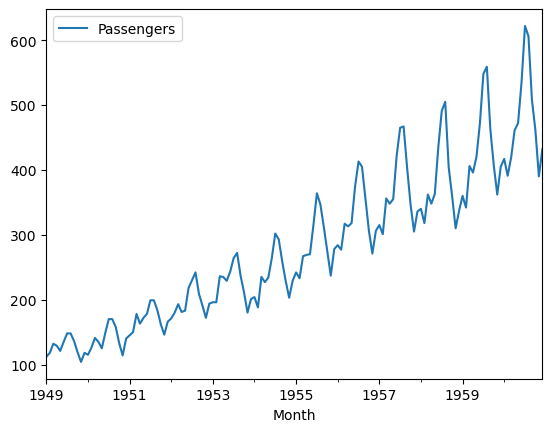

In [4]:
df.plot();

# working WITH differencing

In [5]:
df['LogPassengers'] = np.log(df['Passengers'])

In [6]:
df['DiffLogPassengers'] = df['LogPassengers'].diff()

In [7]:
Ntest = 12
train = df.iloc[:-Ntest]
test = df.iloc[-Ntest:]

In [8]:
series =  df['DiffLogPassengers'].to_numpy()[1:] #1st value is 0 in differencing # converting this to numpy array since it is easy to index

T = 10
X = []
Y = []

for t in range(len(series)-T):
    x = series[t:t+T] # returns from t to t + T -1
    y = series[t+T] # returns t+T
    X.append(x)
    Y.append(y)

X = np.array(X).reshape(-1, T)
Y = np.array(Y)
N = len(X)
print("X.shape", X.shape, "Y.shape", Y.shape)

X.shape (133, 10) Y.shape (133,)


In [9]:
''' Y is one step forecast'''

' Y is one step forecast'

In [10]:
Xtrain, Ytrain = X[:-Ntest], Y[:-Ntest]
Xtest, Ytest = X[-Ntest:], Y[-Ntest:] 

In [11]:
''' the above way is wrong - since it leads to data leakage in test set and evaluation might lead to incorrect answers'''
'''' this is because the actual target label in the test set for each row appears as the 10th (last) feature in the next row of test set''' 

"' this is because the actual target label in the test set for each row appears as the 10th (last) feature in the next row of test set"

In [12]:
lr = LinearRegression()
lr.fit(Xtrain, Ytrain)
lr.score(Xtrain, Ytrain)

0.6837135048453121

In [13]:
lr.score(Xtest, Ytest)

0.6492870172668166

In [16]:
''' r2 is now much lower than when we were not using differencing since the differenced value is now stationary.
predicting just the previous value leads to a high r2 which we saw without differencing - but predicting previous value
in stationary dataset doesnt bode well
'''

' r2 is now much lower than when we were not using differencing since the differenced value is now stationary.\npredicting just the previous value leads to a high r2 which we saw without differencing - but predicting previous value\nin stationary dataset doesnt bode well\n'

In [17]:
train_idx = df.index <= train.index[-1]
test_idx = ~ train_idx
train_idx[:T+1] = False # 1st T+1 values are not predictable since model is trained to predict basis last T values

In [19]:
# need to compute un-differenced predictions  for itrain predictions for one step
df['ShiftLogPassengers'] = df['LogPassengers'].shift(1)
prev = df['ShiftLogPassengers']

In [20]:
# last-known train value - for out of sample or test predictions
last_train = train.iloc[-1]['LogPassengers']

In [21]:
prev.head()

Month
1949-01-01         NaN
1949-02-01    4.718499
1949-03-01    4.770685
1949-04-01    4.882802
1949-05-01    4.859812
Name: ShiftLogPassengers, dtype: float64

In [22]:
df['LogPassengers'].head()

Month
1949-01-01    4.718499
1949-02-01    4.770685
1949-03-01    4.882802
1949-04-01    4.859812
1949-05-01    4.795791
Name: LogPassengers, dtype: float64

In [23]:
lr.predict(Xtrain)

array([ 0.06447711,  0.09621887,  0.06658   ,  0.1437545 , -0.06213318,
        0.06134485,  0.09912761,  0.13805153, -0.07266896, -0.01157083,
       -0.19791556, -0.03927491,  0.03257273,  0.06823722, -0.00596747,
        0.08275148, -0.13850601, -0.02783328,  0.08779488,  0.04590618,
       -0.01447847, -0.10772017, -0.15544527, -0.11516575,  0.10025991,
       -0.02404323,  0.09873275,  0.02334626, -0.01450821,  0.02781638,
        0.0971629 ,  0.0743048 , -0.055206  , -0.05547377, -0.18506909,
       -0.01247382,  0.01205324,  0.08556304, -0.01264156,  0.09276487,
       -0.11529358,  0.03785541,  0.04538643,  0.09307536, -0.04597958,
       -0.06771881, -0.10834247, -0.04114132,  0.07443695,  0.07340117,
        0.07648233,  0.18926851,  0.04088092,  0.05862813,  0.14326096,
        0.09333044, -0.01634881, -0.09304566, -0.07662686, -0.11707864,
        0.10819455, -0.04005699,  0.03395276,  0.04762794, -0.005105  ,
        0.01279829,  0.12929276,  0.07672374, -0.07995207, -0.11

In [24]:
# 1 step forecast
df.loc[train_idx, 'LR_1step_train'] =  prev[train_idx] + lr.predict(Xtrain)
df.loc[test_idx, 'LR_1step_test'] =  prev[test_idx] + lr.predict(Xtest)

In [25]:
print(Xtrain.shape)
print(lr.predict(Xtrain).shape)

(121, 10)
(121,)


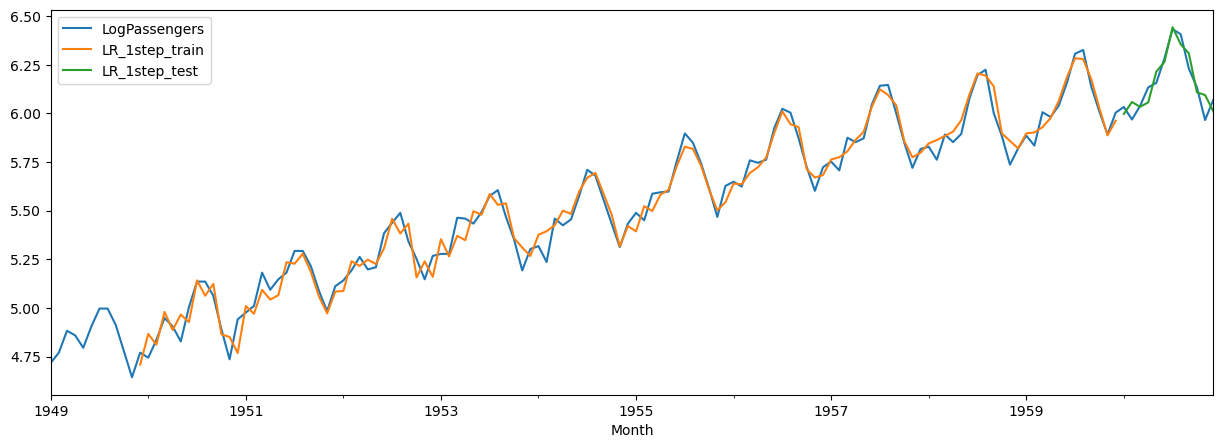

In [26]:
# plot 1 step forecast
df[['LogPassengers','LR_1step_train','LR_1step_test']].plot(figsize = (15,5));

In [28]:
''' no problem reaching the peak when using the differenced data.
this was not the case when model was trained on non-differenced data.
'''

' no problem reaching the peak when using the differenced data.\nthis was not the case when model was trained on non-differenced data.\n'

In [29]:
# multi step forecast
multistep_predictions = []

#first test input
last_x = Xtest[0] # an array of 10 input values for test set

while len(multistep_predictions) < Ntest:
    p = lr.predict(last_x.reshape(1,-1))[0] # since last_x is just one element, the shape gets messed up, we are changing the shape to 1*T 
    #scikit learn accepts data in the shape N*T only
    # at the end putting [0] since we want numeric output and not the array output

    # update the predictions list
    multistep_predictions.append(p)

    # make the new input 
    last_x = np.roll(last_x, -1) #[ 1 2 3 4 5] => [2 3 4 5 1] doing it this way since we cant delete or append anything to an array
    last_x[-1] = p # using the predictions from the previous horizon to make prediction for the next horizon

In [30]:
''' the above is the correct method of multistep - since it is never seeing the actual target label. for the next horizon, it is 
using the previous predicted value of previous horizon'''
''' the above implementation is how statsmodels does it when we call model_res.forecast(Ntest)'''

' the above implementation is how statsmodels does it when we call model_res.forecast(Ntest)'

In [31]:
multistep_predictions

[np.float64(-0.006875093141159),
 np.float64(0.033359266817769226),
 np.float64(0.06483381115279754),
 np.float64(-0.02903115156028624),
 np.float64(0.11169113338560639),
 np.float64(0.10816758494887843),
 np.float64(0.13558992192535815),
 np.float64(-0.04575250590105784),
 np.float64(-0.09795686860426872),
 np.float64(-0.13031998590905078),
 np.float64(-0.07415336551530566),
 np.float64(0.055929181624282606)]

In [32]:
df.loc[test_idx, 'LR_multistep'] = last_train + np.cumsum(multistep_predictions)

In [36]:
''' last known train value plus adding all the deltas - see notes for explanation'''
'''y_pred(t+1) = y_act(t) + pred_delta_y(t+1) # y_act(t) this is the last value from training set'''
'''y_pred(t+2) = y_pred(t+1) + pred_delta_y(t+1) = y_act(t) + pred_delta_y(t+1) + pred_delta_y(t+2)'''

'y_pred(t+2) = y_pred(t+1) + pred_delta_y(t+1) = y_act(t) + pred_delta_y(t+1) + pred_delta_y(t+2)'

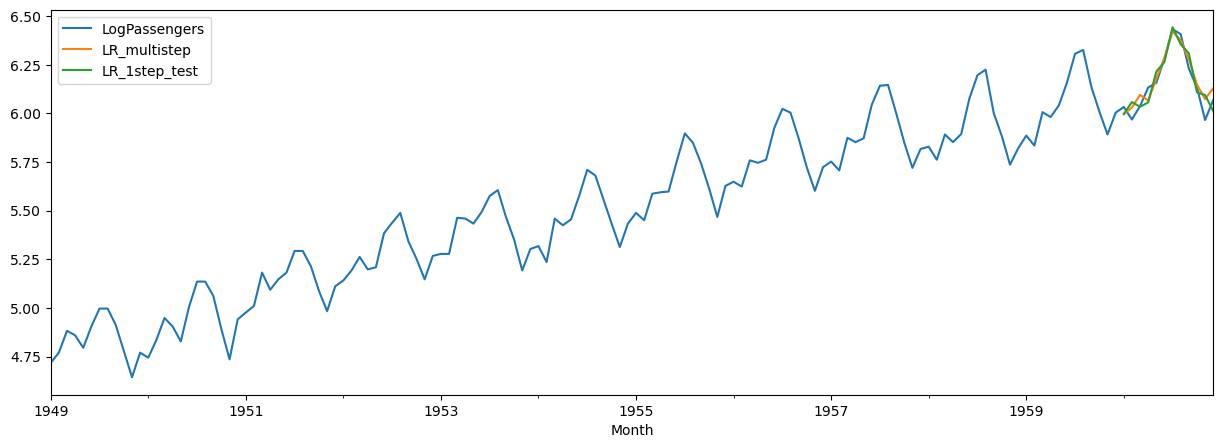

In [33]:
# plot 1 step and multistep forecast
df[['LogPassengers','LR_multistep','LR_1step_test']].plot(figsize = (15,5));

In [37]:
'''multi step also pretty good'''

'multi step also pretty good'

In [38]:
# making multi-output supervised dataset

Tx = T
Ty = Ntest
X = []
Y = []

for t in range(len(series) - Tx - Ty + 1):
    x = series[t:t+Tx]  
    y = series[t+Tx:t+Tx+Ty]  
    X.append(x)
    Y.append(y)
    # 1st x will have data inputs from 0 to 9 # 1st y will have data inputs from 10 to 21
    # 2nd x will have data inputs from 1 to 10 # 2nd y will have data inputs from 11 to 22

X = np.array(X).reshape(-1,Tx)
Y = np.array(Y).reshape(-1,Ty)
N = len(X)
print("X.shape", X.shape, "Y.shape", Y.shape)

# converting this into numpy array since scikit learn only takes numpy array as an input
    

X.shape (122, 10) Y.shape (122, 12)


In [39]:
Xtrain_m, Ytrain_m = X[:-1], Y[:-1]
Xtest_m, Ytest_m = X[-1:], Y[-1:]

In [40]:
lr = LinearRegression()
lr.fit(Xtrain_m, Ytrain_m)
lr.score(Xtrain_m, Ytrain_m)

0.8141637147930583

In [41]:
''' although the r2 values shows improvement, but this is misleading since outputs repeat multiple times in diff rows 
example
- y1, y2, y3 in 1st rows and y2, y3, y4 in 2nd row'''

' although the r2 values shows improvement, but this is misleading since outputs repeat multiple times in diff rows \nexample\n- y1, y2, y3 in 1st rows and y2, y3, y4 in 2nd row'

In [42]:
lr.score(Xtest_m, Ytest_m)

C:\Users\VARUN\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


nan

In [43]:
''' nan = not a number '''

' nan = not a number '

In [44]:
'''r2 denominator calculates variance from mean of diff samples, but since only 1 sample, SST is undefined '''

'r2 denominator calculates variance from mean of diff samples, but since only 1 sample, SST is undefined '

In [45]:
r2_score(lr.predict(Xtest_m).flatten(), Ytest_m.flatten())

0.7690077978619652

In [48]:
'''this is an alternative way of calculating r2, this shows iimprovement. also note that the y labels in test hasnt been seen by the model yet'''
'''r2 here is essentially the deltas and not the actual values - so this is diff than the non differenced model'''

'r2 here is essentially the deltas and not the actual values - so this is diff than the non differenced model'

In [49]:
df.loc[test_idx, 'LR_multioutput'] = last_train + np.cumsum(lr.predict(Xtest_m).flatten())

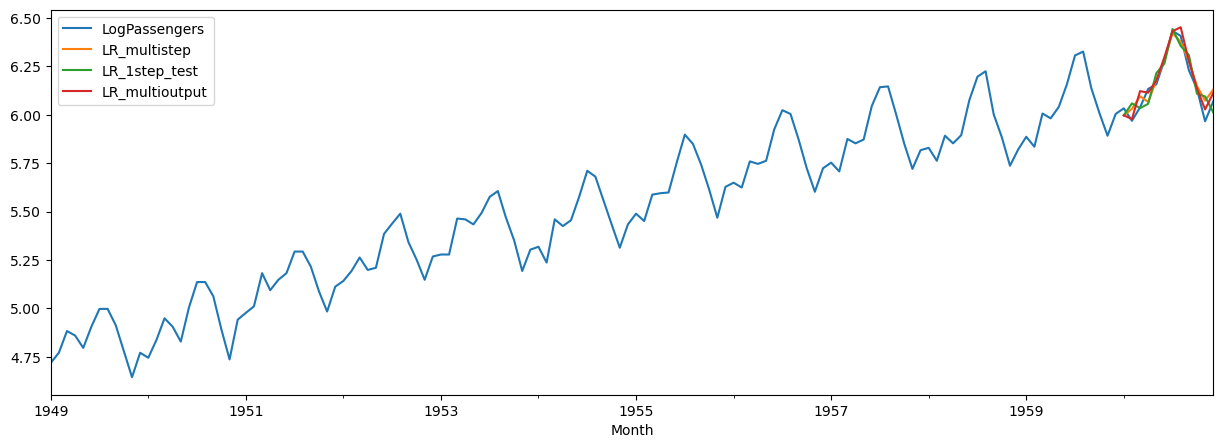

In [50]:
df[['LogPassengers','LR_multistep','LR_1step_test','LR_multioutput']].plot(figsize = (15,5));

In [51]:
'''multioutput also pretty good'''

'multioutput also pretty good'

In [52]:
#MAPE - just checking other metrics
test_log_pass = df.iloc[-Ntest:]['LogPassengers']
mape_1 = mean_absolute_percentage_error(test_log_pass, df.loc[test_idx, 'LR_multistep'])
print("multi-step MAPE:", mape_1)

mape_2 = mean_absolute_percentage_error(test_log_pass, df.loc[test_idx, 'LR_multioutput'])
print("multi-output MAPE:", mape_2)

multi-step MAPE: 0.007109281288502526
multi-output MAPE: 0.005245261617574929


In [53]:
''' multi out mape is bit better '''

' multi out mape is bit better '

## testing other models

In [55]:
def one_step_and_multistep_forecast(model, name):
    model.fit(Xtrain, Ytrain)
    print("One-step forecast:", name)

    # 1 step forecast
    df.loc[train_idx, f'{name}_1step_train'] = prev[train_idx] + model.predict(Xtrain)
    df.loc[test_idx, f'{name}_1step_test'] = prev[test_idx] + model.predict(Xtest)

    #generate multi-step forecast
    multistep_predictions =[]
    last_x = Xtest[0]

    while len(multistep_predictions) < Ntest:
        p = model.predict(last_x.reshape(1,-1))[0]

        multistep_predictions.append(p)

        last_x = np.roll(last_x,-1)
        last_x[-1] = p

    df.loc[test_idx, f'{name}_multistep_test'] = last_train + np.cumsum(multistep_predictions)

    mape = mean_absolute_percentage_error(test_log_pass, df.loc[test_idx, f'{name}_multistep_test'])
    print("Test MAPE (multistep):", mape) 

    cols = [
        'LogPassengers',
        f'{name}_1step_train',
        f'{name}_1step_test',
        f'{name}_multistep_test'
    ]
    
    df[cols].plot(figsize =(15,5));    

One-step forecast: SVR
Test MAPE (multistep): 0.01214912210239275


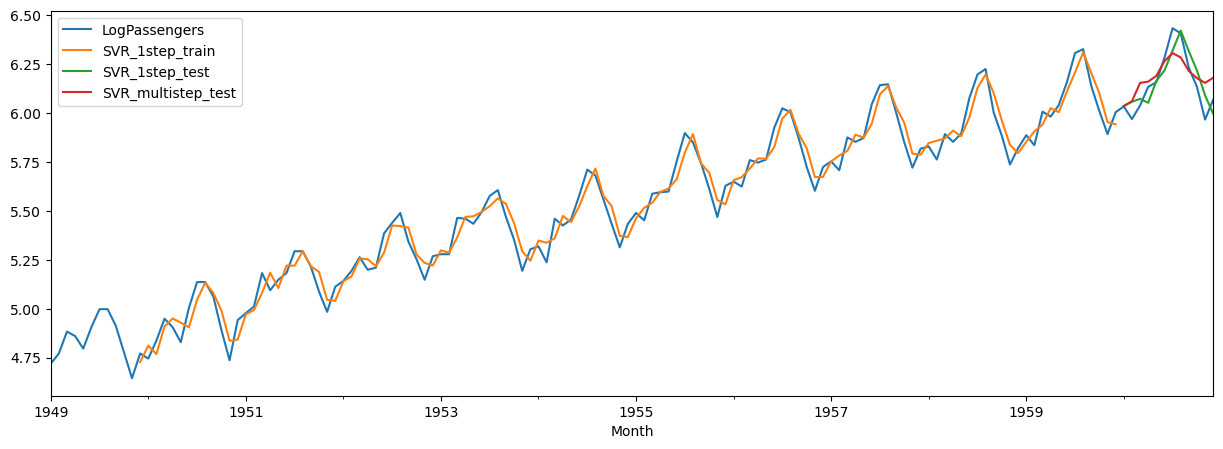

In [56]:
one_step_and_multistep_forecast(SVR(),"SVR")

In [58]:
''' doesnt do too well'''

' doesnt do too well'

One-step forecast: RF
Test MAPE (multistep): 0.005067369898703467


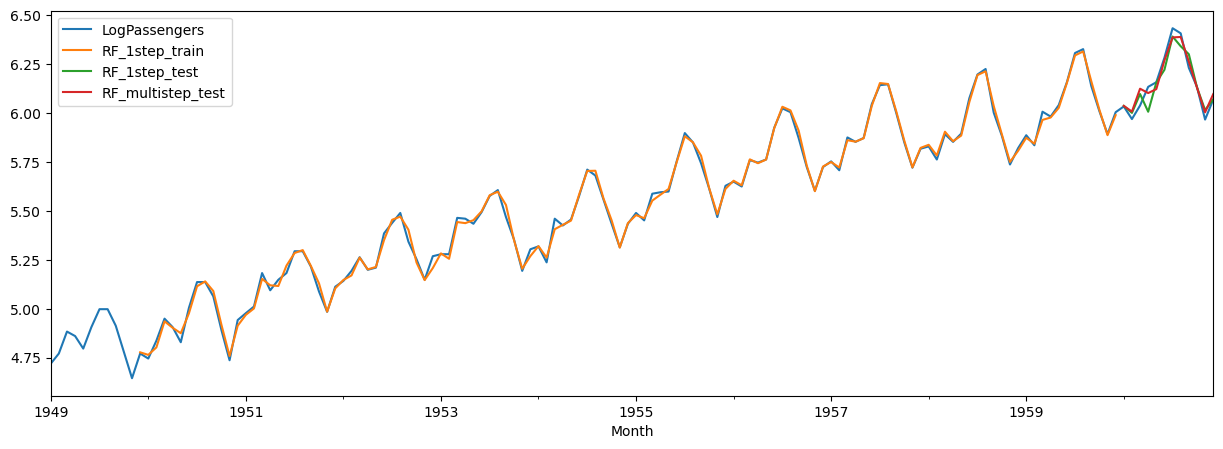

In [59]:
one_step_and_multistep_forecast(RandomForestRegressor(),"RF")

In [60]:
''' this does pretty well in par with linear regression'''

' this does pretty well in par with linear regression'

In [61]:
def multi_output_forecast(model, name):
    
    model.fit(Xtrain_m, Ytrain_m)
    
    # 1 step forecast
    
    df.loc[test_idx, f'{name}_multioutput'] = last_train + np.cumsum(model.predict(Xtest_m).flatten())

    mape = mean_absolute_percentage_error(test_log_pass, df.loc[test_idx, f'{name}_multioutput'])
    print("Test MAPE (multi-output):", mape)
    
    #
    cols = [
        'LogPassengers',
        f'{name}_1step_train',
        f'{name}_1step_test',
        f'{name}_multistep_test',
        f'{name}_multioutput'
    ]
    
    df[cols].plot(figsize =(15,5));    

In [63]:
# multi_output_forecast(SVR(),"SVR")
''' this will throw error since it cannot handle multi-output'''
''' this can still work see - https://www.udemy.com/course/time-series-analysis/learn/lecture/26847864#notes
see time 5:21'''

' this can still work see - https://www.udemy.com/course/time-series-analysis/learn/lecture/26847864#notes\nsee time 5:21'

Test MAPE (multi-output): 0.005026900601985136


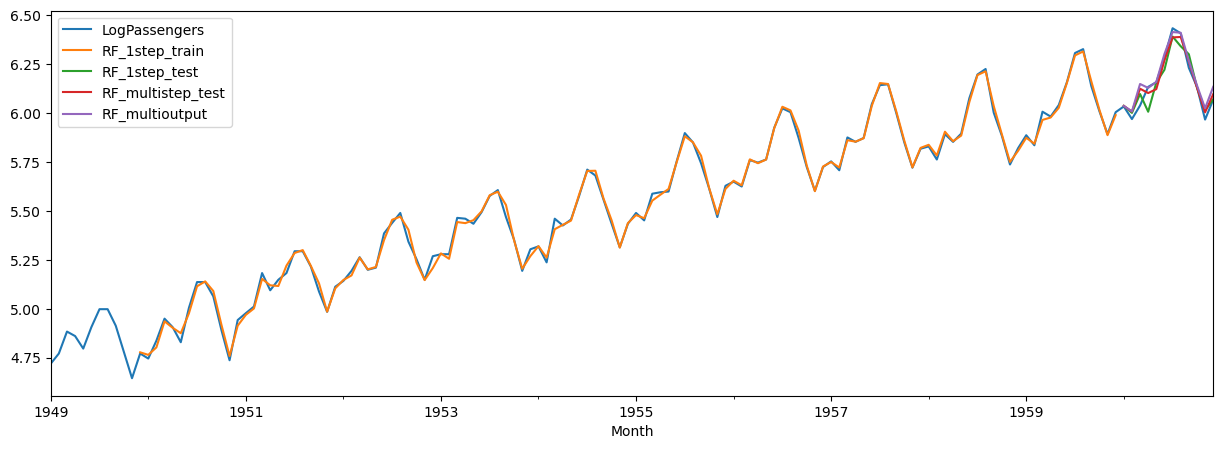

In [64]:
multi_output_forecast(RandomForestRegressor(),"RF")

In [66]:
''' performs well after we use differencing in the model - wasnt performing well when we didnt use differencing''' 

' performs well after we use differencing in the model - wasnt performing well when we didnt use differencing'

# conclusion - differencing improves the model performance overall